# Modular Fair-RAG Recreation (T5 Small + BM25)

This notebook is designed to scale across machines by changing only one config profile.

Profiles:
- `weak`: 5 queries, small samples
- `balanced`: more queries and samples
- `strong`: intended for a better machine/full recreation

Output focus: normalized EE-D interval buckets (`0.0-0.2 ... 0.8-1.0`) and EU differences.

In [1]:
from pathlib import Path
import importlib
import pandas as pd

import notebook_experiment_utils as neu
importlib.reload(neu)

ExperimentConfig = neu.ExperimentConfig
find_repo_root = neu.find_repo_root
resolve_python_executable = neu.resolve_python_executable
ensure_paths_exist = neu.ensure_paths_exist
run_experiment_for_alpha = neu.run_experiment_for_alpha
run_gold_baseline = neu.run_gold_baseline
run_retriever_grid = neu.run_retriever_grid
run_deterministic_reference = neu.run_deterministic_reference
run_mmr_deterministic = neu.run_mmr_deterministic
normalize_eu_grid = neu.normalize_eu_grid
normalize_eu_for_retriever = neu.normalize_eu_for_retriever
load_normalized_rows = neu.load_normalized_rows
load_normalized_rows_for_retriever = neu.load_normalized_rows_for_retriever
load_raw_rows = neu.load_raw_rows
add_ee_d_interval_bins = neu.add_ee_d_interval_bins
summarize_by_interval = neu.summarize_by_interval
interval_pvalues_vs_deterministic = neu.interval_pvalues_vs_deterministic
save_interval_outputs = neu.save_interval_outputs
save_per_query_log = neu.save_per_query_log
save_pvalue_outputs = neu.save_pvalue_outputs
reset_run_outputs = neu.reset_run_outputs
assert_consistent_qids_across_alphas = neu.assert_consistent_qids_across_alphas


In [2]:
ROOT = find_repo_root()
PY = resolve_python_executable(ROOT)

profiles = {
    'weak': {
        'max_queries': 30,
        'n_samples': 10,
        'k': 5,
        'print_interval': 10,
    },
    'balanced': {
        'max_queries': 833,
        'n_samples': 12,
        'k': 5,
        'print_interval': 40,
    },
    'strong': {
        'max_queries': None,
        'n_samples': 100,
        'k': 5,
        'print_interval': 100,
    },
}

# Change only this line when moving to a stronger machine
profile_name = 'balanced'
profile = profiles[profile_name]

cfg = ExperimentConfig(
    root=ROOT,
    python_exe=PY,
    generator_name='flanT5Small',
    lamp_num=4,
    retriever_name='bm25',
    alphas=(1, 2, 4, 8),
    max_queries=profile['max_queries'],
    n_samples=profile['n_samples'],
    k=profile['k'],
    remove_temp_files=True,
    skip_existing=True,
    mmr_base_retriever='bm25',
    mmr_lambda=0.6,
    run_tag=profile_name,
    print_interval=profile['print_interval'],
 )

ensure_paths_exist([cfg.python_exe])

print('Root   :', ROOT)
print('Python :', cfg.python_exe)
print('Profile:', profile_name)
print('Config :', cfg)


Root   : /home/student/Fair-RAG
Python : /anaconda/envs/azureml_py310_sdkv2/bin/python3.10
Profile: balanced
Config : ExperimentConfig(root=PosixPath('/home/student/Fair-RAG'), python_exe=PosixPath('/anaconda/envs/azureml_py310_sdkv2/bin/python3.10'), generator_name='flanT5Small', lamp_num=4, retriever_name='bm25', alphas=(1, 2, 4, 8), max_queries=833, n_samples=12, k=5, remove_temp_files=True, skip_existing=True, mmr_base_retriever='bm25', mmr_lambda=0.6, run_tag='balanced', print_interval=40)


## Run Controls
Toggle stages independently. Baselines run first (deterministic BM25 + deterministic MMR).

In [3]:
RUN_GOLD = True
RUN_DETERMINISTIC_REF = True
RUN_MMR_DETERMINISTIC = True
RUN_MMR_LAMBDA_SWEEP = False   # already chose lambda=0.6; no sweep needed
RUN_BASELINE_SUMMARY = True

RUN_BM25_GRID = True
RUN_NORMALIZE_EU = True
RUN_SANITY = True
RUN_ANALYSIS = True

# Deterministic references use one alpha only; value is for naming consistency.
DETERMINISTIC_ALPHA = 1
MMR_LAMBDAS = (0.6,)

# Sanity checks: oracle + stochastic BM25 across alphas on a small subset.
SANITY_MAX_QUERIES = 12
SANITY_N_SAMPLES = 10
SANITY_ALPHAS = (1, 2, 4, 8)
SANITY_GOLD_ALPHA = 8
SANITY_OUTPUT_SUFFIX = '_sanity'

# IMPORTANT for long runs on unstable servers:
# Keep this False so completed outputs are preserved and reruns resume safely.
FORCE_FRESH_RUN = False


In [4]:
import time
from datetime import datetime


def run_stage(name, enabled, fn):
    if not enabled:
        print(f'[skip] {name}')
        return
    print(f"\n=== START {name} @ {datetime.now().strftime('%H:%M:%S')} ===")
    t0 = time.time()
    fn()
    dt_sec = time.time() - t0
    print(f'=== DONE {name} in {dt_sec/60:.2f} min ===')


def build_sanity_cfg():
    return ExperimentConfig(
        root=cfg.root,
        python_exe=cfg.python_exe,
        generator_name=cfg.generator_name,
        lamp_num=cfg.lamp_num,
        retriever_name=cfg.retriever_name,
        alphas=SANITY_ALPHAS,
        max_queries=SANITY_MAX_QUERIES,
        n_samples=SANITY_N_SAMPLES,
        k=cfg.k,
        remove_temp_files=cfg.remove_temp_files,
        skip_existing=False,
        mmr_base_retriever=cfg.mmr_base_retriever,
        mmr_lambda=cfg.mmr_lambda,
    )


def build_cfg_with_mmr_lambda(mmr_lambda):
    return ExperimentConfig(
        root=cfg.root,
        python_exe=cfg.python_exe,
        generator_name=cfg.generator_name,
        lamp_num=cfg.lamp_num,
        retriever_name=cfg.retriever_name,
        alphas=cfg.alphas,
        max_queries=cfg.max_queries,
        n_samples=cfg.n_samples,
        k=cfg.k,
        remove_temp_files=cfg.remove_temp_files,
        skip_existing=cfg.skip_existing,
        mmr_base_retriever=cfg.mmr_base_retriever,
        mmr_lambda=mmr_lambda,
    )


def mmr_lambda_suffix(mmr_lambda):
    return f"_mmr_lambda_{mmr_lambda:.1f}".replace('.', 'p')


def run_sanity_checks():
    sanity_cfg = build_sanity_cfg()
    print(
        'Sanity config:',
        {
            'max_queries': sanity_cfg.max_queries,
            'n_samples': sanity_cfg.n_samples,
            'alphas': sanity_cfg.alphas,
            'suffix': SANITY_OUTPUT_SUFFIX,
        },
    )

    run_experiment_for_alpha(
        sanity_cfg,
        retriever_name='gold',
        alpha=SANITY_GOLD_ALPHA,
        output_suffix=SANITY_OUTPUT_SUFFIX,
    )

    for alpha in sanity_cfg.alphas:
        run_experiment_for_alpha(
            sanity_cfg,
            retriever_name=sanity_cfg.retriever_name,
            alpha=alpha,
            output_suffix=SANITY_OUTPUT_SUFFIX,
        )

    df_st = load_raw_rows(
        sanity_cfg,
        sanity_cfg.retriever_name,
        sanity_cfg.alphas,
        output_suffix=SANITY_OUTPUT_SUFFIX,
    )
    df_oracle = load_raw_rows(
        sanity_cfg,
        'gold',
        (SANITY_GOLD_ALPHA,),
        output_suffix=SANITY_OUTPUT_SUFFIX,
    )

    st_summary = (
        df_st.groupby('alpha', as_index=False)
        .agg(
            n_qids=('qid', 'nunique'),
            mean_ee_d=('ee_d', 'mean'),
            mean_ee_r=('ee_r', 'mean'),
            mean_eu=('eu', 'mean'),
        )
        .sort_values('alpha')
        .reset_index(drop=True)
    )

    oracle_summary = pd.DataFrame(
        [
            {
                'alpha': f'gold@{SANITY_GOLD_ALPHA}',
                'n_qids': df_oracle['qid'].nunique(),
                'mean_ee_d': df_oracle['ee_d'].mean(),
                'mean_ee_r': df_oracle['ee_r'].mean(),
                'mean_eu': df_oracle['eu'].mean(),
            }
        ]
    )

    print('\nSanity summary: stochastic BM25 by alpha')
    display(st_summary)
    print('Sanity summary: oracle gold anchor')
    display(oracle_summary)


def run_mmr_lambda_sweep():
    for mmr_lambda in MMR_LAMBDAS:
        mmr_cfg = build_cfg_with_mmr_lambda(mmr_lambda)
        run_mmr_deterministic(
            mmr_cfg,
            alpha=DETERMINISTIC_ALPHA,
            output_suffix=mmr_lambda_suffix(mmr_lambda),
        )


def load_mmr_lambda_sweep_rows():
    rows = []
    for mmr_lambda in MMR_LAMBDAS:
        df_lambda = load_raw_rows(
            cfg,
            'mmr',
            (DETERMINISTIC_ALPHA,),
            output_suffix=mmr_lambda_suffix(mmr_lambda),
        )
        rows.append(
            {
                'mmr_lambda': mmr_lambda,
                'n_qids': df_lambda['qid'].nunique(),
                'mean_ee_r': df_lambda['ee_r'].mean(),
                'mean_eu': df_lambda['eu'].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values('mmr_lambda').reset_index(drop=True)


def show_deterministic_baselines():
    df_bm25 = load_raw_rows(
        cfg,
        cfg.retriever_name,
        (DETERMINISTIC_ALPHA,),
        output_suffix='_deterministic',
    )
    df_mmr = load_raw_rows(
        cfg,
        'mmr',
        (DETERMINISTIC_ALPHA,),
        output_suffix='_mmr_deterministic',
    )

    baseline_summary = pd.DataFrame(
        [
            {
                'retriever': f'{cfg.retriever_name}_deterministic',
                'alpha': DETERMINISTIC_ALPHA,
                'n_qids': df_bm25['qid'].nunique(),
                'mean_ee_r': df_bm25['ee_r'].mean(),
                'mean_eu': df_bm25['eu'].mean(),
            },
            {
                'retriever': 'mmr_deterministic',
                'alpha': DETERMINISTIC_ALPHA,
                'n_qids': df_mmr['qid'].nunique(),
                'mean_ee_r': df_mmr['ee_r'].mean(),
                'mean_eu': df_mmr['eu'].mean(),
            },
        ]
    )

    print('\nDeterministic baselines (raw EU and EE-R):')
    display(baseline_summary)


def show_mmr_lambda_sweep():
    sweep_summary = load_mmr_lambda_sweep_rows()
    print('\nDeterministic MMR lambda sweep (raw EU and EE-R):')
    display(sweep_summary)


if FORCE_FRESH_RUN:
    run_stage('reset outputs', True, lambda: reset_run_outputs(cfg, include_gold=True))

# Baselines first
run_stage('gold baseline (alpha=8)', RUN_GOLD, lambda: run_gold_baseline(cfg, alpha=8))
run_stage(
    'deterministic BM25 baseline',
    RUN_DETERMINISTIC_REF,
    lambda: run_deterministic_reference(
        cfg, alpha=DETERMINISTIC_ALPHA, output_suffix='_deterministic'
    ),
)
run_stage(
    'deterministic MMR baseline',
    RUN_MMR_DETERMINISTIC,
    lambda: run_mmr_deterministic(
        cfg, alpha=DETERMINISTIC_ALPHA, output_suffix='_mmr_deterministic'
    ),
)
run_stage('MMR lambda sweep (0.0 to 1.0)', RUN_MMR_LAMBDA_SWEEP, run_mmr_lambda_sweep)
run_stage('baseline summary (EU, EE-R)', RUN_BASELINE_SUMMARY, show_deterministic_baselines)
run_stage('MMR lambda sweep summary', RUN_MMR_LAMBDA_SWEEP, show_mmr_lambda_sweep)

# Full BM25 experiment stages
run_stage('BM25 alpha grid', RUN_BM25_GRID, lambda: run_retriever_grid(cfg))

def _normalize_stage():
    assert_consistent_qids_across_alphas(cfg, cfg.retriever_name)
    normalize_eu_grid(cfg)

run_stage('EU normalization (BM25 grid)', RUN_NORMALIZE_EU, _normalize_stage)
run_stage('sanity checks (oracle + stochastic alpha sweep)', RUN_SANITY, run_sanity_checks)


=== START gold baseline (alpha=8) @ 10:09:05 ===
[skip] alpha_8.json  (833 queries) EE-D=0.4120  EE-R=0.9831  EU=0.0737
=== DONE gold baseline (alpha=8) in 0.00 min ===

=== START deterministic BM25 baseline @ 10:09:05 ===
[skip] alpha_1_deterministic.json  (833 queries) EE-D=1.0000  EE-R=0.3158  EU=0.0480
=== DONE deterministic BM25 baseline in 0.00 min ===

=== START deterministic MMR baseline @ 10:09:05 ===
[skip] alpha_1_mmr_deterministic.json  (833 queries) EE-D=1.0000  EE-R=0.3109  EU=0.0492
=== DONE deterministic MMR baseline in 0.00 min ===
[skip] MMR lambda sweep (0.0 to 1.0)

=== START baseline summary (EU, EE-R) @ 10:09:05 ===

Deterministic baselines (raw EU and EE-R):


,retriever,alpha,n_qids,mean_ee_r,mean_eu
0,bm25_deterministic,1,833,0.315762,0.048012
1,mmr_deterministic,1,833,0.310872,0.049176


=== DONE baseline summary (EU, EE-R) in 0.00 min ===
[skip] MMR lambda sweep summary

=== START BM25 alpha grid @ 10:09:05 ===
[skip] alpha_1.json  (833 queries) EE-D=0.1933  EE-R=0.2842  EU=0.0399
[skip] alpha_2.json  (833 queries) EE-D=0.2405  EE-R=0.2885  EU=0.0413
[skip] alpha_4.json  (833 queries) EE-D=0.7088  EE-R=0.3107  EU=0.0479
[skip] alpha_8.json  (833 queries) EE-D=0.9586  EE-R=0.3146  EU=0.0482
=== DONE BM25 alpha grid in 0.00 min ===

=== START EU normalization (BM25 grid) @ 10:09:05 ===
[skip] existing: /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_normalized.json
[skip] existing: /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_2_normalized.json
[skip] existing: /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_4_normalized.json
[skip] existing: /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_8_normalized.json
=== DONE EU normalization (BM25 grid) in 0.00 min ===

=== START sani

,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu
0,1,12,0.188667,0.205447,0.021648
1,2,12,0.240000,0.198781,0.020350
2,4,12,0.718667,0.166157,0.031739
3,8,12,0.977333,0.156738,0.023437


Sanity summary: oracle gold anchor


,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu
0,gold@8,12,0.513,0.990238,0.054106


=== DONE sanity checks (oracle + stochastic alpha sweep) in 14.13 min ===


## Baseline-First Results, MMR Lambda Sweep, and BM25 Grid Analysis

In [5]:
if RUN_ANALYSIS:
    # 1) Deterministic baseline comparison first (raw EU/EE-R).
    df_det = load_raw_rows(
        cfg,
        cfg.retriever_name,
        (DETERMINISTIC_ALPHA,),
        output_suffix='_deterministic',
    )
    df_mmr = load_raw_rows(
        cfg,
        'mmr',
        (DETERMINISTIC_ALPHA,),
        output_suffix='_mmr_deterministic',
    )

    baseline_compare = pd.DataFrame(
        [
            {
                'retriever': f'{cfg.retriever_name}_deterministic',
                'alpha': DETERMINISTIC_ALPHA,
                'n_qids': df_det['qid'].nunique(),
                'mean_ee_r': df_det['ee_r'].mean(),
                'mean_eu': df_det['eu'].mean(),
            },
            {
                'retriever': 'mmr_deterministic',
                'alpha': DETERMINISTIC_ALPHA,
                'n_qids': df_mmr['qid'].nunique(),
                'mean_ee_r': df_mmr['ee_r'].mean(),
                'mean_eu': df_mmr['eu'].mean(),
            },
        ]
    )
    print('Deterministic baselines first (raw EU and EE-R):')
    display(baseline_compare)

    # 2) Deterministic MMR lambda sweep before stochastic BM25 experiments.
    mmr_lambda_summary = load_mmr_lambda_sweep_rows()
    print('\nDeterministic MMR lambda sweep (raw EU and EE-R):')
    display(mmr_lambda_summary)

    # 3) BM25 normalized alpha-grid interval report.
    df = load_normalized_rows(cfg)
    df = add_ee_d_interval_bins(df)
    summary = summarize_by_interval(df)

    print(
        f'\nAnalyzing normalized BM25 alpha-grid for retriever: {cfg.retriever_name} '
        '(oracle gold excluded; used only as normalization reference)'
    )
    print('Per-query rows (BM25 alpha grid):', len(df))
    display(summary)

    # Deterministic interval views on raw scale.
    df_det_binned = add_ee_d_interval_bins(df_det)
    summary_det = summarize_by_interval(df_det_binned)
    print('\nDeterministic BM25 reference (raw EE/EU):')
    display(summary_det)

    df_mmr_binned = add_ee_d_interval_bins(df_mmr)
    summary_mmr = summarize_by_interval(df_mmr_binned)
    print('\nDeterministic MMR reference (raw EE/EU):')
    display(summary_mmr)

    out_name = f'notebook_outputs_{profile_name}'
    summary_fp = save_interval_outputs(cfg, summary, out_name)
    perq_fp = save_per_query_log(cfg, df, out_name)

    # Significance: MMR deterministic vs BM25 deterministic on raw deterministic metrics.
    pvals_ee_r = interval_pvalues_vs_deterministic(df_mmr_binned, df_det_binned, metric='ee_r')
    pvals_eu = interval_pvalues_vs_deterministic(df_mmr_binned, df_det_binned, metric='eu')
    pvals = pd.concat([pvals_ee_r, pvals_eu], ignore_index=True)

    pvals = pvals[pvals['n_qids'] > 0].copy()
    pvals = (
        pvals[[
            'ee_d_interval',
            'metric',
            'n_qids',
            'p_two_sided',
        ]]
        .sort_values(['ee_d_interval', 'metric'])
        .reset_index(drop=True)
    )
    display(pvals)
    pvals_fp = save_pvalue_outputs(cfg, pvals, out_name)

    print('Saved:')
    print(' -', summary_fp)
    print(' -', perq_fp)
    print(' -', pvals_fp)
else:
    print('Skipping analysis')

Deterministic baselines first (raw EU and EE-R):


,retriever,alpha,n_qids,mean_ee_r,mean_eu
0,bm25_deterministic,1,833,0.315762,0.048012
1,mmr_deterministic,1,833,0.310872,0.049176



Deterministic MMR lambda sweep (raw EU and EE-R):


,mmr_lambda,n_qids,mean_ee_r,mean_eu
0,0.6,30,0.176028,0.025545



Analyzing normalized BM25 alpha-grid for retriever: bm25 (oracle gold excluded; used only as normalization reference)
Per-query rows (BM25 alpha grid): 3332


...


Deterministic MMR reference (raw EE/EU):


/home/student/Fair-RAG/notebook_experiment_utils.py:548: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby("ee_d_interval", dropna=False)


,ee_d_interval,n_queries,mean_eu,mean_ee_d,mean_ee_r
0,0.0-0.2,0,NaN,NaN,NaN
1,0.2-0.4,0,NaN,NaN,NaN
2,0.4-0.6,0,NaN,NaN,NaN
3,0.6-0.8,0,NaN,NaN,NaN
4,0.8-1.0,833,0.049176,1.0,0.310872


,ee_d_interval,metric,n_qids,p_two_sided
0,0.8-1.0,ee_r,833,0.030520
1,0.8-1.0,eu,833,0.329275


Saved:
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/ee_d_interval_summary.csv
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/per_query_all_metrics.csv
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/pvalues_vs_deterministic_by_interval.csv


## Normalized Deterministic Runs + Pairwise Graphs

This section:
- ensures normalized files exist for deterministic BM25 and deterministic MMR
- does not overwrite any existing outputs (`skip_existing=True` for this step)
- plots normalized pairs: (EE-R, EU), (EE-D, EE-R), (EE-D, EU)


> /anaconda/envs/azureml_py310_sdkv2/bin/python3.10 normalize_eu.py --generator_name flanT5Small --lamp_num 4 --retriever_name bm25 --alpha 1 --all_alphas 1 --input_suffix _deterministic

> /anaconda/envs/azureml_py310_sdkv2/bin/python3.10 normalize_eu.py --generator_name flanT5Small --lamp_num 4 --retriever_name mmr --alpha 1 --all_alphas 1 --input_suffix _mmr_deterministic
Rows loaded for plotting: 4998
Series: ['bm25_a1', 'bm25_a2', 'bm25_a4', 'bm25_a8', 'bm25_deterministic', 'mmr_deterministic']


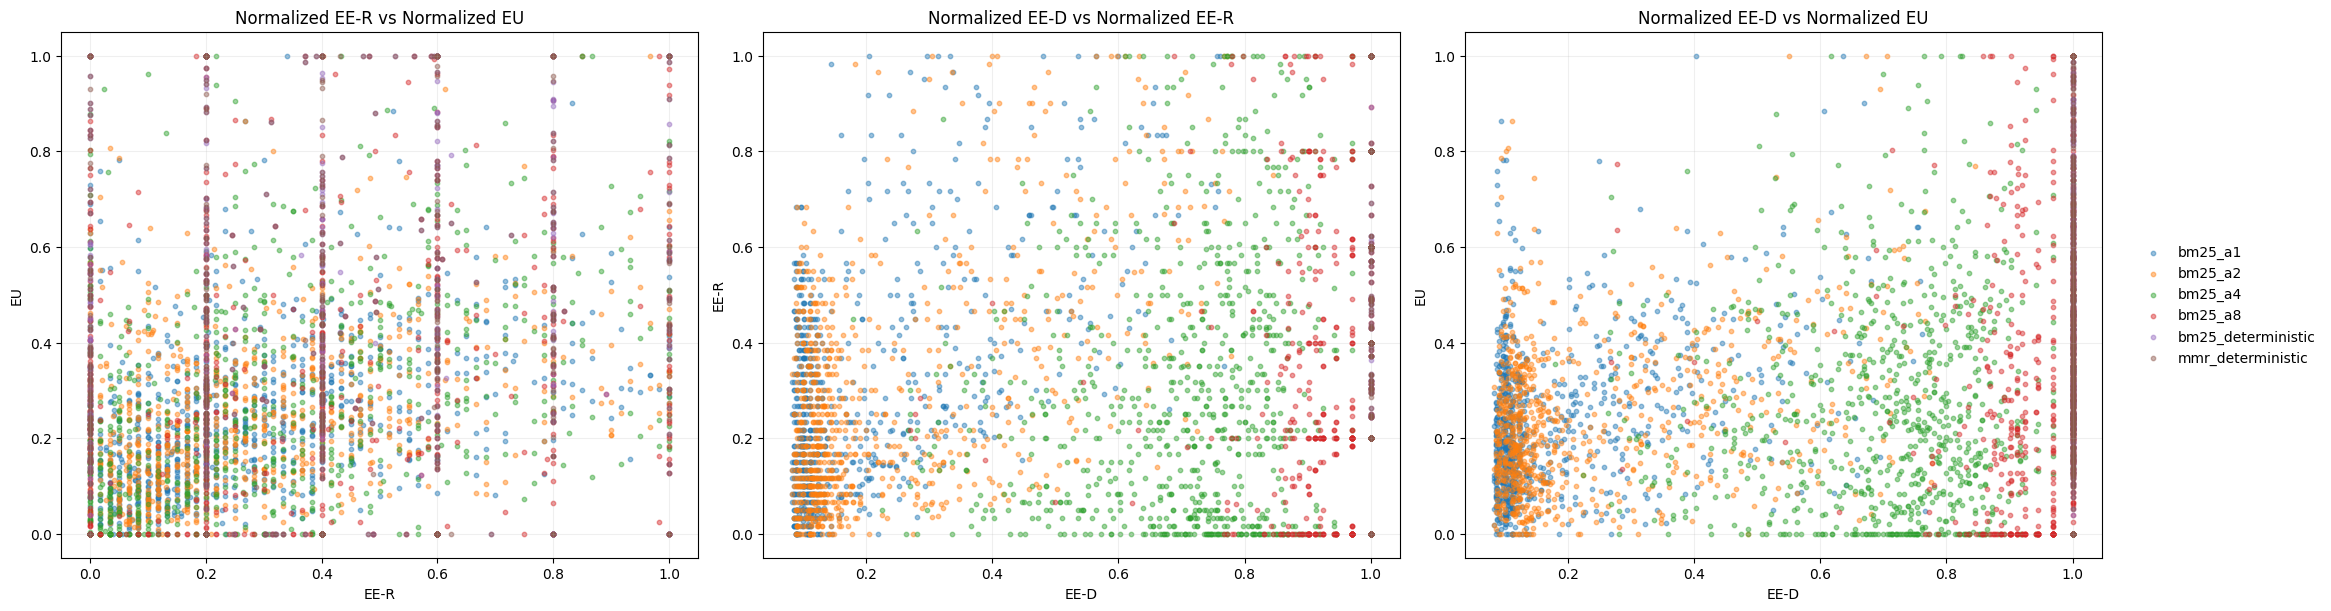

In [6]:
import matplotlib.pyplot as plt

# Keep this section non-destructive: never overwrite normalized outputs.
_prev_skip_existing = cfg.skip_existing
cfg.skip_existing = True

# Ensure deterministic normalized files exist (safe: skip if already present).
normalize_eu_for_retriever(
    cfg,
    retriever_name=cfg.retriever_name,
    alpha=DETERMINISTIC_ALPHA,
    output_suffix='_deterministic',
)
normalize_eu_for_retriever(
    cfg,
    retriever_name='mmr',
    alpha=DETERMINISTIC_ALPHA,
    output_suffix='_mmr_deterministic',
)

# Load normalized data.
df_bm25_norm = load_normalized_rows(cfg).copy()
df_bm25_norm['series'] = df_bm25_norm['alpha'].map(lambda a: f'bm25_a{a}')

df_bm25_det_norm = load_normalized_rows_for_retriever(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_deterministic',
).copy()
df_bm25_det_norm['series'] = f'{cfg.retriever_name}_deterministic'

df_mmr_det_norm = load_normalized_rows_for_retriever(
    cfg,
    retriever_name='mmr',
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_mmr_deterministic',
).copy()
df_mmr_det_norm['series'] = 'mmr_deterministic'

df_plot = pd.concat([df_bm25_norm, df_bm25_det_norm, df_mmr_det_norm], ignore_index=True)

# Restore original setting for later cells.
cfg.skip_existing = _prev_skip_existing

print('Rows loaded for plotting:', len(df_plot))
print('Series:', sorted(df_plot['series'].unique()))

# Pairwise normalized plots requested by user.
pairs = [
    ('ee_r', 'eu', 'Normalized EE-R vs Normalized EU'),
    ('ee_d', 'ee_r', 'Normalized EE-D vs Normalized EE-R'),
    ('ee_d', 'eu', 'Normalized EE-D vs Normalized EU'),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for ax, (x_col, y_col, title) in zip(axes, pairs):
    for series_name, g in df_plot.groupby('series', sort=True):
        ax.scatter(g[x_col], g[y_col], s=10, alpha=0.45, label=series_name)
    ax.set_xlabel(x_col.upper().replace('_', '-'))
    ax.set_ylabel(y_col.upper().replace('_', '-'))
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

# Keep legend outside so plots stay readable.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.show()

## Per-Alpha Mean Graphs (BM25 Only) + Normalized Settings Summary

This section:
- plots per-alpha averages for BM25 only (excludes gold and MMR from the plots)
- prints normalized EU summaries for BM25 alphas, deterministic BM25, deterministic MMR, and gold
- prints key experiment settings used in this notebook

[11:34:31] Start: per-alpha mean plots + normalized settings summary
[11:34:31] RUN_MISSING_NORMALIZATION=False
[11:34:31] Step 1: file presence check
[11:34:31] [exists] (required) bm25_alpha_1_normalized -> /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_normalized.json
[11:34:31] [exists] (required) bm25_alpha_2_normalized -> /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_2_normalized.json
[11:34:31] [exists] (required) bm25_alpha_4_normalized -> /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_4_normalized.json
[11:34:31] [exists] (required) bm25_alpha_8_normalized -> /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_8_normalized.json
[11:34:31] [exists] (optional) bm25_alpha_1_deterministic_normalized -> /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_deterministic_normalized.json
[11:34:31] [exists] (optional) mmr_alpha_1_mmr_deterministic_normalized -> /home/stude

,run,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu_normalized
0,bm25_deterministic,1,833,1.000000,0.315762,0.310867
1,bm25_stochastic,1,833,0.193321,0.284190,0.236684
2,bm25_stochastic,2,833,0.240523,0.288537,0.243259
3,bm25_stochastic,4,833,0.708750,0.310704,0.266322
4,bm25_stochastic,8,833,0.958577,0.314613,0.268959
5,mmr_deterministic,1,833,1.000000,0.310872,0.316099


[11:34:31] Step 5: BM25 per-alpha mean plots (+ deterministic as alpha=inf, same line)


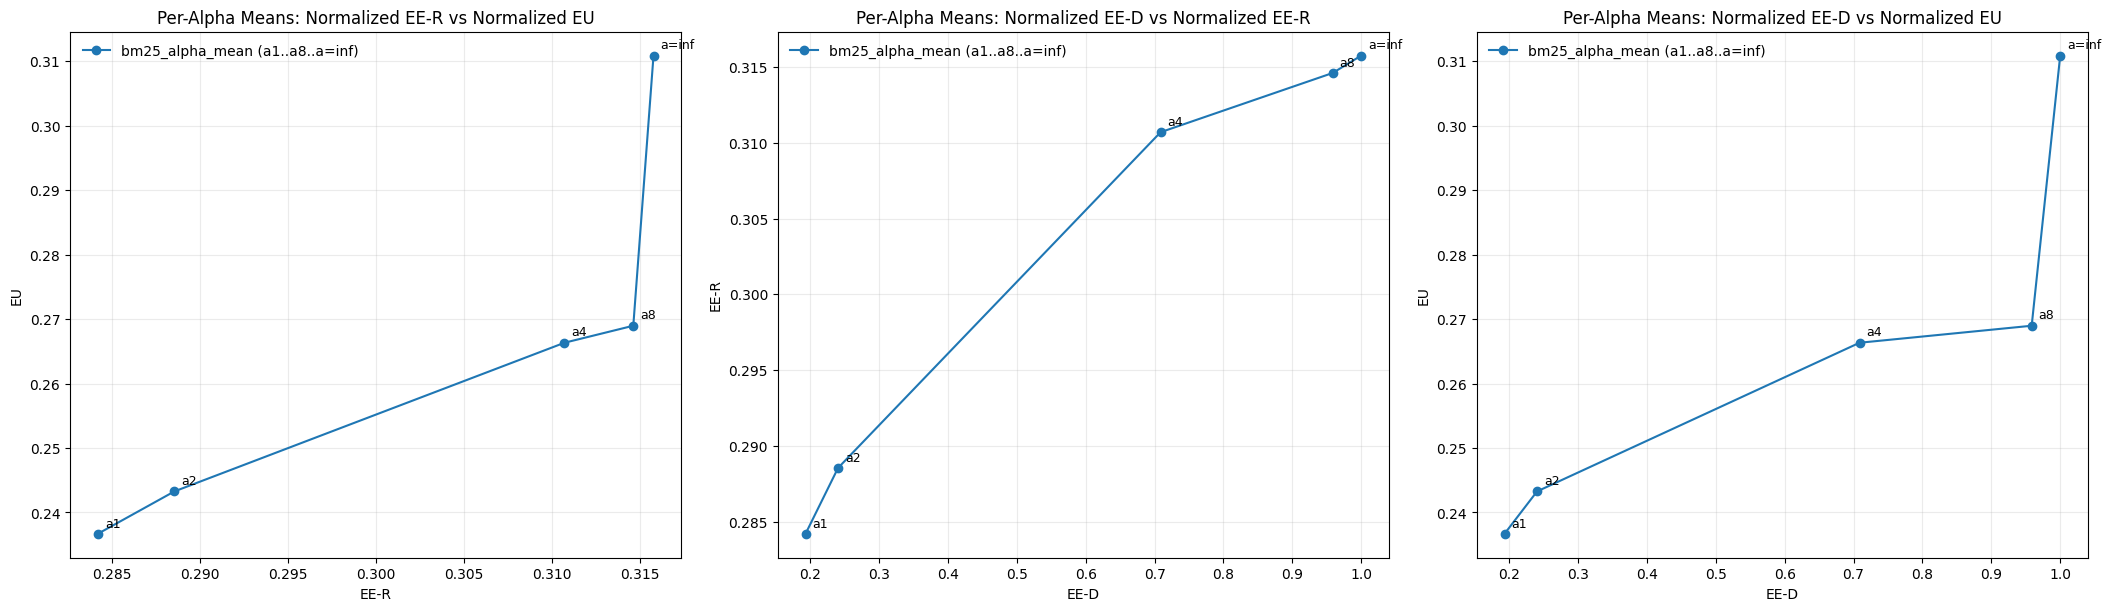

[11:34:32] Done


In [7]:
import time
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt

# Keep False for fast, non-destructive behavior.
# If True, only missing normalized JSONs are generated (no overwrite).
RUN_MISSING_NORMALIZATION = False

def _ts() -> str:
    return datetime.now().strftime('%H:%M:%S')

def _status(msg: str) -> None:
    print(f"[{_ts()}] {msg}", flush=True)

def _normalized_fp(retriever_name: str, alpha: int, output_suffix: str = '') -> Path:
    suffix = output_suffix
    if suffix and not suffix.startswith('_'):
        suffix = f'_{suffix}'
    return (
        cfg.root
        / 'experiment_results'
        / cfg.generator_name
        / f'lamp{cfg.lamp_num}'
        / retriever_name
        / f'alpha_{alpha}{suffix}_normalized.json'
    )

_status('Start: per-alpha mean plots + normalized settings summary')
_status(f'RUN_MISSING_NORMALIZATION={RUN_MISSING_NORMALIZATION}')

required_files = []
# BM25 stochastic normalized files (REQUIRED for the per-alpha plots)
for alpha in cfg.alphas:
    required_files.append({
        'name': f'bm25_alpha_{alpha}_normalized',
        'retriever': cfg.retriever_name,
        'alpha': alpha,
        'suffix': '',
        'required': True,
        'fp': _normalized_fp(cfg.retriever_name, alpha, ''),
    })

# Optional for settings summary only
required_files.extend([
    {
        'name': f'bm25_alpha_{DETERMINISTIC_ALPHA}_deterministic_normalized',
        'retriever': cfg.retriever_name,
        'alpha': DETERMINISTIC_ALPHA,
        'suffix': '_deterministic',
        'required': False,
        'fp': _normalized_fp(cfg.retriever_name, DETERMINISTIC_ALPHA, '_deterministic'),
    },
    {
        'name': f'mmr_alpha_{DETERMINISTIC_ALPHA}_mmr_deterministic_normalized',
        'retriever': 'mmr',
        'alpha': DETERMINISTIC_ALPHA,
        'suffix': '_mmr_deterministic',
        'required': False,
        'fp': _normalized_fp('mmr', DETERMINISTIC_ALPHA, '_mmr_deterministic'),
    },
    {
        'name': f'gold_alpha_{SANITY_GOLD_ALPHA}_normalized',
        'retriever': 'gold',
        'alpha': SANITY_GOLD_ALPHA,
        'suffix': '',
        'required': False,
        'fp': _normalized_fp('gold', SANITY_GOLD_ALPHA, ''),
    },
])

_status('Step 1: file presence check')
missing = []
for item in required_files:
    exists = item['fp'].exists()
    state = 'exists' if exists else 'missing'
    req = 'required' if item['required'] else 'optional'
    _status(f"[{state}] ({req}) {item['name']} -> {item['fp']}")
    if not exists:
        missing.append(item)

if missing and RUN_MISSING_NORMALIZATION:
    _status(f'Step 2: normalizing {len(missing)} missing file(s) only (skip_existing=True)')
    _prev_skip_existing = cfg.skip_existing
    cfg.skip_existing = True
    try:
        for item in missing:
            _status(
                f"[run ] normalize retriever={item['retriever']} alpha={item['alpha']} suffix={item['suffix'] or 'plain'}"
            )
            t0 = time.time()
            normalize_eu_for_retriever(
                cfg,
                retriever_name=item['retriever'],
                alpha=item['alpha'],
                output_suffix=item['suffix'],
            )
            _status(f"[done] {item['name']} in {time.time() - t0:.1f}s")
    finally:
        cfg.skip_existing = _prev_skip_existing

# Recompute missing after optional normalization pass.
missing_now = [item for item in required_files if not item['fp'].exists()]
missing_required = [item for item in missing_now if item['required']]
missing_optional = [item for item in missing_now if not item['required']]

if missing_optional:
    _status('Optional normalized files still missing; they will be skipped in summary:')
    for item in missing_optional:
        _status(f"[skip] {item['name']}")

if missing_required:
    _status('Required BM25 normalized alpha files are missing; cannot build per-alpha plots.')
    _status('To auto-create missing files, set RUN_MISSING_NORMALIZATION=True and rerun this cell.')
    raise RuntimeError(f"Missing required files: {[x['name'] for x in missing_required]}")

_status('Step 3: load normalized dataframes')
t0_load = time.time()

bm25_norm = load_normalized_rows(cfg).copy()
bm25_mean = (
    bm25_norm.groupby('alpha', as_index=False)
    .agg(
        n_qids=('qid', 'nunique'),
        mean_ee_d=('ee_d', 'mean'),
        mean_ee_r=('ee_r', 'mean'),
        mean_eu=('eu', 'mean'),
    )
    .sort_values('alpha')
    .reset_index(drop=True)
)

# Optional summary components: load only if file exists.
bm25_det_norm = None
mmr_det_norm = None
gold_norm = None

bm25_det_fp = _normalized_fp(cfg.retriever_name, DETERMINISTIC_ALPHA, '_deterministic')
if bm25_det_fp.exists():
    bm25_det_norm = load_normalized_rows_for_retriever(
        cfg,
        retriever_name=cfg.retriever_name,
        alphas=(DETERMINISTIC_ALPHA,),
        output_suffix='_deterministic',
    )

mmr_det_fp = _normalized_fp('mmr', DETERMINISTIC_ALPHA, '_mmr_deterministic')
if mmr_det_fp.exists():
    mmr_det_norm = load_normalized_rows_for_retriever(
        cfg,
        retriever_name='mmr',
        alphas=(DETERMINISTIC_ALPHA,),
        output_suffix='_mmr_deterministic',
    )

gold_fp = _normalized_fp('gold', SANITY_GOLD_ALPHA, '')
if gold_fp.exists():
    gold_norm = load_normalized_rows_for_retriever(
        cfg,
        retriever_name='gold',
        alphas=(SANITY_GOLD_ALPHA,),
        output_suffix='',
    )

_status(f'Step 3 complete in {time.time()-t0_load:.1f}s')

def _mean_row(df, label, alpha):
    return {
        'run': label,
        'alpha': alpha,
        'n_qids': int(df['qid'].nunique()),
        'mean_ee_d': float(df['ee_d'].mean()),
        'mean_ee_r': float(df['ee_r'].mean()),
        'mean_eu_normalized': float(df['eu'].mean()),
    }

summary_rows = []
for _, r in bm25_mean.iterrows():
    summary_rows.append({
        'run': 'bm25_stochastic',
        'alpha': int(r['alpha']),
        'n_qids': int(r['n_qids']),
        'mean_ee_d': float(r['mean_ee_d']),
        'mean_ee_r': float(r['mean_ee_r']),
        'mean_eu_normalized': float(r['mean_eu']),
    })

if bm25_det_norm is not None:
    summary_rows.append(_mean_row(bm25_det_norm, 'bm25_deterministic', DETERMINISTIC_ALPHA))
else:
    _status('Summary skip: bm25_deterministic normalized file missing')

if mmr_det_norm is not None:
    summary_rows.append(_mean_row(mmr_det_norm, 'mmr_deterministic', DETERMINISTIC_ALPHA))
else:
    _status('Summary skip: mmr_deterministic normalized file missing')

if gold_norm is not None:
    summary_rows.append(_mean_row(gold_norm, 'gold', SANITY_GOLD_ALPHA))
else:
    _status('Summary skip: gold normalized file missing')

normalized_summary = pd.DataFrame(summary_rows).sort_values(['run', 'alpha']).reset_index(drop=True)

_status('Step 4: print settings + normalized summary')
print('profile_name          =', profile_name)
print('retriever             =', cfg.retriever_name)
print('generator             =', cfg.generator_name)
print('lamp_num              =', cfg.lamp_num)
print('all_alphas            =', cfg.alphas)
print('deterministic_alpha   =', DETERMINISTIC_ALPHA)
print('gold_alpha            =', SANITY_GOLD_ALPHA)
print('mmr_lambdas           =', MMR_LAMBDAS)
print('run flags:')
print(' RUN_GOLD              =', RUN_GOLD)
print(' RUN_DETERMINISTIC_REF =', RUN_DETERMINISTIC_REF)
print(' RUN_MMR_DETERMINISTIC =', RUN_MMR_DETERMINISTIC)
print(' RUN_MMR_LAMBDA_SWEEP  =', RUN_MMR_LAMBDA_SWEEP)
print(' RUN_BM25_GRID         =', RUN_BM25_GRID)
print(' RUN_NORMALIZE_EU      =', RUN_NORMALIZE_EU)
print(' RUN_SANITY            =', RUN_SANITY)
print(' RUN_ANALYSIS          =', RUN_ANALYSIS)

print('\nNormalized Summary (available runs):')
display(normalized_summary)

_status('Step 5: BM25 per-alpha mean plots (+ deterministic as alpha=inf, same line)')
pair_specs = [
    ('mean_ee_r', 'mean_eu', 'Per-Alpha Means: Normalized EE-R vs Normalized EU'),
    ('mean_ee_d', 'mean_ee_r', 'Per-Alpha Means: Normalized EE-D vs Normalized EE-R'),
    ('mean_ee_d', 'mean_eu', 'Per-Alpha Means: Normalized EE-D vs Normalized EU'),
]

# Aggregate deterministic BM25 point once so we can append it to the same polyline.
bm25_det_point = None
if bm25_det_norm is not None:
    bm25_det_point = {
        'mean_ee_d': float(bm25_det_norm['ee_d'].mean()),
        'mean_ee_r': float(bm25_det_norm['ee_r'].mean()),
        'mean_eu': float(bm25_det_norm['eu'].mean()),
    }

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for ax, (x_col, y_col, title) in zip(axes, pair_specs):
    x_vals = bm25_mean[x_col].tolist()
    y_vals = bm25_mean[y_col].tolist()
    point_labels = [f"a{int(a)}" for a in bm25_mean['alpha'].tolist()]

    if bm25_det_point is not None:
        x_vals.append(bm25_det_point[x_col])
        y_vals.append(bm25_det_point[y_col])
        point_labels.append('a=inf')

    # Single BM25 line including deterministic point as alpha=inf.
    ax.plot(
        x_vals,
        y_vals,
        '-o',
        linewidth=1.5,
        markersize=6,
        label='bm25_alpha_mean (a1..a8..a=inf)' if bm25_det_point is not None else 'bm25_alpha_mean (finite alpha)',
    )

    for x, y, lbl in zip(x_vals, y_vals, point_labels):
        ax.annotate(
            lbl,
            (x, y),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
        )

    ax.set_xlabel(x_col.replace('mean_', '').upper().replace('_', '-'))
    ax.set_ylabel(y_col.replace('mean_', '').upper().replace('_', '-'))
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

plt.show()
_status('Done')

## Interval Tables (Normalized)

This section builds:
- Table A: normalized EU by EE-D disparity interval
- Table B (Table-2 style): normalized EU difference (stochastic - deterministic) by EE-D interval

In [9]:
import pandas as pd

print('Building normalized interval tables (pooled across alphas)...')

# Load normalized stochastic BM25 (all configured alphas).
df_st = load_normalized_rows(cfg).copy()

# Load normalized deterministic BM25 (alpha=1 deterministic file).
df_det = load_normalized_rows_for_retriever(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_deterministic',
).copy()

# Half-open disparity intervals requested by user: [0.0-0.2), [0.2-0.4), ...
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.000001]
labels = ['[0.0-0.2)', '[0.2-0.4)', '[0.4-0.6)', '[0.6-0.8)', '[0.8-1.0]']

df_st['ee_d_interval'] = pd.cut(
    df_st['ee_d'], bins=bins, labels=labels, include_lowest=True, right=False
)

# --- Table A: normalized EU by disparity interval (pooled across alphas) ---
table_a = (
    df_st.groupby('ee_d_interval', observed=False)
    .agg(
        n_rows=('qid', 'count'),
        n_unique_qids=('qid', 'nunique'),
        mean_ee_d=('ee_d', 'mean'),
        mean_ee_r=('ee_r', 'mean'),
        mean_eu=('eu', 'mean'),
    )
    .reset_index()
    .sort_values('ee_d_interval')
    .reset_index(drop=True)
)

print('\nTable A: Normalized EU by EE-D disparity interval (pooled over all alphas)')
display(table_a)

# --- Table B: Table-2 style EU deltas (stochastic - deterministic) by interval ---
# Bin by stochastic EE-D interval, then compare EU on same qids against deterministic.
det_eu_by_qid = df_det.groupby('qid', as_index=False)['eu'].mean().rename(columns={'eu': 'eu_det'})

table_b_rows = []
for interval in labels:
    st_slice = df_st[df_st['ee_d_interval'].astype(str) == interval][['qid', 'eu', 'ee_d', 'ee_r']].copy()

    if st_slice.empty:
        table_b_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic': float('nan'),
            'mean_eu_deterministic': float('nan'),
            'eu_diff_st_minus_det': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    # Multiple rows per qid may exist (from different alphas).
    # Keep one stochastic value per qid by averaging across its stochastic rows in this interval.
    st_by_qid = (
        st_slice.groupby('qid', as_index=False)
        .agg(
            eu=('eu', 'mean'),
            ee_d=('ee_d', 'mean'),
            ee_r=('ee_r', 'mean'),
        )
    )

    paired = st_by_qid.merge(det_eu_by_qid, on='qid', how='inner')
    n_qids = paired['qid'].nunique()

    if n_qids == 0:
        table_b_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic': float('nan'),
            'mean_eu_deterministic': float('nan'),
            'eu_diff_st_minus_det': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    mean_st = float(paired['eu'].mean())
    mean_det = float(paired['eu_det'].mean())
    table_b_rows.append({
        'ee_d_interval': interval,
        'n_qids': int(n_qids),
        'mean_eu_stochastic': mean_st,
        'mean_eu_deterministic': mean_det,
        'eu_diff_st_minus_det': mean_st - mean_det,
        'mean_ee_d_stochastic': float(paired['ee_d'].mean()),
        'mean_ee_r_stochastic': float(paired['ee_r'].mean()),
    })

table_b = pd.DataFrame(table_b_rows).sort_values('ee_d_interval').reset_index(drop=True)

print('\nTable B (Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)')
display(table_b)

# Save interval-only tables.
out_dir = (
    cfg.root
    / 'experiment_results'
    / cfg.generator_name
    / f'lamp{cfg.lamp_num}'
    / cfg.retriever_name
    / f'notebook_outputs_{profile_name}'
)
out_dir.mkdir(parents=True, exist_ok=True)
table_a_fp = out_dir / 'tableA_normalized_eu_by_disparity_interval_pooled.csv'
table_b_fp = out_dir / 'tableB_eu_diff_st_minus_det_by_disparity_interval_pooled.csv'
table_a.to_csv(table_a_fp, index=False)
table_b.to_csv(table_b_fp, index=False)

print('\nSaved tables:')
print(' -', table_a_fp)
print(' -', table_b_fp)

Building normalized interval tables (pooled across alphas)...

Table A: Normalized EU by EE-D disparity interval (pooled over all alphas)


,ee_d_interval,n_rows,n_unique_qids,mean_ee_d,mean_ee_r,mean_eu
0,[0.0-0.2),1106,581,0.118789,0.207468,0.206509
1,[0.2-0.4),350,259,0.295960,0.338559,0.265691
2,[0.4-0.6),316,275,0.499481,0.384886,0.293129
3,[0.6-0.8),497,452,0.710843,0.357234,0.282670
4,[0.8-1.0],1063,804,0.944669,0.330053,0.273918



Table B (Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)


,ee_d_interval,n_qids,mean_eu_stochastic,mean_eu_deterministic,eu_diff_st_minus_det,mean_ee_d_stochastic,mean_ee_r_stochastic
0,[0.0-0.2),581,0.205669,0.271237,-0.065568,0.121214,0.209077
1,[0.2-0.4),259,0.259791,0.341552,-0.081761,0.298654,0.337426
2,[0.4-0.6),275,0.284829,0.347482,-0.062653,0.499675,0.370179
3,[0.6-0.8),452,0.267542,0.305239,-0.037697,0.711835,0.319770
4,[0.8-1.0],804,0.266558,0.308803,-0.042244,0.950623,0.313180



Saved tables:
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableA_normalized_eu_by_disparity_interval_pooled.csv
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableB_eu_diff_st_minus_det_by_disparity_interval_pooled.csv


## Interval Tables (Raw EU, Non-Normalized)

Same pooled interval analysis as above, but using non-normalized EU from raw experiment outputs.

In [10]:
import pandas as pd

print('Building raw-EU interval tables (pooled across alphas)...')

# Load RAW stochastic BM25 (all configured alphas).
df_st_raw = load_raw_rows(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=cfg.alphas,
    output_suffix='',
).copy()

# Load RAW deterministic BM25 (alpha=1 deterministic file).
df_det_raw = load_raw_rows(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_deterministic',
).copy()

# Same half-open disparity intervals: [0.0-0.2), [0.2-0.4), ...
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.000001]
labels = ['[0.0-0.2)', '[0.2-0.4)', '[0.4-0.6)', '[0.6-0.8)', '[0.8-1.0]']

df_st_raw['ee_d_interval'] = pd.cut(
    df_st_raw['ee_d'], bins=bins, labels=labels, include_lowest=True, right=False
)

# --- Table A (RAW): EU by disparity interval (pooled across alphas) ---
table_a_raw = (
    df_st_raw.groupby('ee_d_interval', observed=False)
    .agg(
        n_rows=('qid', 'count'),
        n_unique_qids=('qid', 'nunique'),
        mean_ee_d=('ee_d', 'mean'),
        mean_ee_r=('ee_r', 'mean'),
        mean_eu_raw=('eu', 'mean'),
    )
    .reset_index()
    .sort_values('ee_d_interval')
    .reset_index(drop=True)
)

print('\nTable A (RAW): EU by EE-D disparity interval (pooled over all alphas)')
display(table_a_raw)

# --- Table B (RAW): Table-2 style EU deltas (stochastic - deterministic) by interval ---
det_eu_by_qid_raw = df_det_raw.groupby('qid', as_index=False)['eu'].mean().rename(columns={'eu': 'eu_det_raw'})

table_b_raw_rows = []
for interval in labels:
    st_slice = df_st_raw[df_st_raw['ee_d_interval'].astype(str) == interval][['qid', 'eu', 'ee_d', 'ee_r']].copy()

    if st_slice.empty:
        table_b_raw_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic_raw': float('nan'),
            'mean_eu_deterministic_raw': float('nan'),
            'eu_diff_st_minus_det_raw': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    # Multiple rows per qid may exist (from different alphas).
    # Keep one stochastic value per qid by averaging across its stochastic rows in this interval.
    st_by_qid = (
        st_slice.groupby('qid', as_index=False)
        .agg(
            eu=('eu', 'mean'),
            ee_d=('ee_d', 'mean'),
            ee_r=('ee_r', 'mean'),
        )
    )

    paired = st_by_qid.merge(det_eu_by_qid_raw, on='qid', how='inner')
    n_qids = paired['qid'].nunique()

    if n_qids == 0:
        table_b_raw_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic_raw': float('nan'),
            'mean_eu_deterministic_raw': float('nan'),
            'eu_diff_st_minus_det_raw': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    mean_st = float(paired['eu'].mean())
    mean_det = float(paired['eu_det_raw'].mean())
    table_b_raw_rows.append({
        'ee_d_interval': interval,
        'n_qids': int(n_qids),
        'mean_eu_stochastic_raw': mean_st,
        'mean_eu_deterministic_raw': mean_det,
        'eu_diff_st_minus_det_raw': mean_st - mean_det,
        'mean_ee_d_stochastic': float(paired['ee_d'].mean()),
        'mean_ee_r_stochastic': float(paired['ee_r'].mean()),
    })

table_b_raw = pd.DataFrame(table_b_raw_rows).sort_values('ee_d_interval').reset_index(drop=True)

print('\nTable B (RAW, Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)')
display(table_b_raw)

# Save raw interval-only tables next to normalized outputs.
out_dir = (
    cfg.root
    / 'experiment_results'
    / cfg.generator_name
    / f'lamp{cfg.lamp_num}'
    / cfg.retriever_name
    / f'notebook_outputs_{profile_name}'
)
out_dir.mkdir(parents=True, exist_ok=True)
table_a_raw_fp = out_dir / 'tableA_raw_eu_by_disparity_interval_pooled.csv'
table_b_raw_fp = out_dir / 'tableB_raw_eu_diff_st_minus_det_by_disparity_interval_pooled.csv'
table_a_raw.to_csv(table_a_raw_fp, index=False)
table_b_raw.to_csv(table_b_raw_fp, index=False)

print('\nSaved raw tables:')
print(' -', table_a_raw_fp)
print(' -', table_b_raw_fp)

Building raw-EU interval tables (pooled across alphas)...

Table A (RAW): EU by EE-D disparity interval (pooled over all alphas)


,ee_d_interval,n_rows,n_unique_qids,mean_ee_d,mean_ee_r,mean_eu_raw
0,[0.0-0.2),1106,581,0.118789,0.207468,0.032586
1,[0.2-0.4),350,259,0.295960,0.338559,0.054542
2,[0.4-0.6),316,275,0.499481,0.384886,0.049643
3,[0.6-0.8),497,452,0.710843,0.357234,0.050271
4,[0.8-1.0],1063,804,0.944669,0.330053,0.048820



Table B (RAW, Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)


,ee_d_interval,n_qids,mean_eu_stochastic_raw,mean_eu_deterministic_raw,eu_diff_st_minus_det_raw,mean_ee_d_stochastic,mean_ee_r_stochastic
0,[0.0-0.2),581,0.032601,0.042184,-0.009584,0.121214,0.209077
1,[0.2-0.4),259,0.051992,0.055496,-0.003504,0.298654,0.337426
2,[0.4-0.6),275,0.049057,0.053525,-0.004468,0.499675,0.370179
3,[0.6-0.8),452,0.047974,0.047033,0.000941,0.711835,0.319770
4,[0.8-1.0],804,0.047702,0.047482,0.000220,0.950623,0.313180



Saved raw tables:
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableA_raw_eu_by_disparity_interval_pooled.csv
 - /home/student/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableB_raw_eu_diff_st_minus_det_by_disparity_interval_pooled.csv


In [ ]:
# Force a true balanced rerun (833 queries) instead of reusing existing weak outputs.
cfg.skip_existing = False
FORCE_FRESH_RUN = True

print('Forced rerun settings:')
print(' profile_name      =', profile_name)
print(' cfg.max_queries   =', cfg.max_queries)
print(' cfg.skip_existing =', cfg.skip_existing)
print(' FORCE_FRESH_RUN   =', FORCE_FRESH_RUN)
print(' MMR_LAMBDAS       =', MMR_LAMBDAS)

Current deterministic MMR lambda sweep summary (raw EU and EE-R):


,mmr_lambda,n_qids,mean_ee_r,mean_eu
0,0.0,30,0.113333,0.015120
1,0.1,30,0.133333,0.019047
2,0.2,30,0.173333,0.013905
3,0.3,30,0.169362,0.020878
4,0.4,30,0.169362,0.025200
5,0.5,30,0.176028,0.022288
6,0.6,30,0.176028,0.025545
7,0.7,30,0.189362,0.024094
8,0.8,30,0.182695,0.021256
9,0.9,30,0.182695,0.021184


In [1]:
# ===== Run Status Inspector =====
# Shows the latest N runs: status (completed / interrupted), config, and metrics.
#
# To RESUME an interrupted run:
#   1. Make sure FORCE_FRESH_RUN = False (Cell 4)
#   2. Re-run Cells 1-2 (imports) and Cell 5 (pipeline)
#   The checkpoint is auto-detected and the run continues from where it left off.

from pathlib import Path
import json
import pandas as pd

# ---------- Config ----------
N_RECENT_RUNS = 5      # how many recent runs to list (newest first); 1 = latest only
RUN_TAG_FILTER = None  # narrow by tag, e.g. "balanced", "weak", or None for all
# ----------------------------

try:
    _runs_dir = ROOT / "experiment_results" / "runs"
except NameError:
    _runs_dir = Path("experiment_results/runs").resolve()

if not _runs_dir.exists() or not any(_runs_dir.iterdir()):
    print("No runs found yet. Run the pipeline (Cell 5) first.")
else:
    _all_runs = sorted(
        [d for d in _runs_dir.iterdir() if d.is_dir()],
        key=lambda d: d.name,
        reverse=True,
    )
    if RUN_TAG_FILTER:
        _all_runs = [d for d in _all_runs if RUN_TAG_FILTER in d.name]

    _runs_to_show = _all_runs[:N_RECENT_RUNS]
    print(f"Total runs found : {len(_all_runs)}")
    if RUN_TAG_FILTER:
        print(f"Tag filter       : '{RUN_TAG_FILTER}'")
    print(f"Showing latest   : {len(_runs_to_show)}\n")

    for _run_dir in _runs_to_show:
        _params_fp  = _run_dir / "params.json"
        _progress_fp = _run_dir / "progress.csv"

        if not _params_fp.exists():
            print(f"  {_run_dir.name}  [no params.json — skipping]\n")
            continue

        _p       = json.loads(_params_fp.read_text())
        _is_done = bool(_p.get("completed_at"))
        _status  = "COMPLETED" if _is_done else "INTERRUPTED / IN PROGRESS"

        print("=" * 70)
        print(f"  {_run_dir.name}")
        print(f"  Status    : {_status}")
        print(f"  Started   : {_p.get('started_at', '?')}")
        if _is_done:
            print(f"  Finished  : {_p.get('completed_at', '?')}")
        print(
            f"  Config    : retriever={_p.get('retriever','?')} | alpha={_p.get('alpha','?')}"
            f" | suffix={_p.get('output_suffix') or '(none)'}"
            f" | n_samples={_p.get('n_samples','?')}"
            f" | max_queries={_p.get('max_queries','?')}"
            f" | tag={_p.get('run_tag') or '(none)'}"
        )
        if _p.get("mmr_lambda") is not None:
            print(f"  MMR lambda: {_p['mmr_lambda']}")

        # --- Progress ---
        if _progress_fp.exists():
            _df = pd.read_csv(_progress_fp)
            if not _df.empty:
                _last      = _df.iloc[-1]
                _processed = int(_last["query_count"])
                _total_raw = _last["total_queries"]
                try:
                    _total_int = int(_total_raw)
                    _total_str = str(_total_int)
                    _pct_str   = f"{100.0 * _processed / _total_int:.0f}%"
                except (ValueError, TypeError):
                    _total_str = "?"
                    _pct_str   = "?"
                print(f"  Progress  : {_processed} / {_total_str} queries ({_pct_str})")
                print(
                    f"  Last avg  :"
                    f"  EE-D={float(_last['mean_ee_d']):.4f}"
                    f"  EE-R={float(_last['mean_ee_r']):.4f}"
                    f"  EU={float(_last['mean_eu']):.4f}"
                )
                if len(_df) > 1:
                    _disp = _df[["timestamp", "query_count", "total_queries",
                                 "mean_ee_d", "mean_ee_r", "mean_eu"]].copy()
                    _disp.columns = ["timestamp", "q_done", "q_total", "EE-D", "EE-R", "EU"]
                    print(f"\n  Progress log ({len(_df)} checkpoints):")
                    print(_disp.to_string(index=False, float_format="{:.4f}".format))
            else:
                print("  Progress  : progress.csv is empty")
        else:
            print("  Progress  : no progress.csv (run killed before first checkpoint)")

        # --- Output / checkpoint files ---
        _out_fp_str = _p.get("output_file")
        if _out_fp_str:
            _out_fp  = Path(_out_fp_str)
            _ckpt_fp = Path(_out_fp_str[:-5] + "_ckpt.json")
            print(f"  Output    : {'EXISTS' if _out_fp.exists() else 'MISSING'} — {_out_fp.name}")
            print(
                f"  Checkpoint: {'EXISTS (resume ready)' if _ckpt_fp.exists() else 'not present'}"
                f" — {_ckpt_fp.name}"
            )

        # --- Resume / restart guidance ---
        if not _is_done:
            print()
            if _out_fp_str:
                _ckpt_fp = Path(_out_fp_str[:-5] + "_ckpt.json")
                if _ckpt_fp.exists():
                    _ckpt_count = len(json.loads(_ckpt_fp.read_text()).get("results", {}))
                    print(f"  >> RESUME : checkpoint has {_ckpt_count} queries saved.")
                    print(f"     Keep FORCE_FRESH_RUN = False, then re-run Cells 1-2 and Cell 5.")
                    print(f"     The run will skip {_ckpt_count} already-processed queries.")
                else:
                    print(f"  >> RESTART: no checkpoint found — run will start from scratch.")
                    print(f"     Keep FORCE_FRESH_RUN = False and re-run Cells 1-2 and Cell 5.")

        print()


Total runs found : 1
Showing latest   : 1

  20260325_212333_gold_alpha8_plain_flanT5Small_lamp4_nq833_balanced
  Status    : INTERRUPTED / IN PROGRESS
  Started   : 2026-03-25T21:23:33
  Config    : retriever=gold | alpha=8 | suffix=(none) | n_samples=12 | max_queries=833 | tag=balanced
  Progress  : 680 / 833 queries (82%)
  Last avg  :  EE-D=0.3847  EE-R=0.9870  EU=0.0751

  Progress log (68 checkpoints):
          timestamp  q_done  q_total   EE-D   EE-R     EU
2026-03-25T21:27:16      10      833 0.5269 0.9921 0.0476
2026-03-25T21:30:36      20      833 0.4893 0.9922 0.0627
2026-03-25T21:33:54      30      833 0.4406 0.9944 0.0623
2026-03-25T21:36:55      40      833 0.4135 0.9956 0.0651
2026-03-25T21:39:58      50      833 0.3862 0.9965 0.0665
2026-03-25T21:42:35      60      833 0.3821 0.9944 0.0701
2026-03-25T21:45:54      70      833 0.3978 0.9948 0.0703
2026-03-25T21:49:23      80      833 0.4083 0.9948 0.0673
2026-03-25T21:53:02      90      833 0.4304 0.9902 0.0663
2026-03-